# Hurricane Maria – San Juan EDA V2

## Key Features
1. **No cloud summary file** – images pre-screened during download
2. **Differentiated buffer**: airport 1250m, others 750m
3. **Per-type resilience analysis** with separate curves
4. **Satellite basemap** for POI/buffer and brighter-pixel maps
5. **Best post image selection** for NTL change ratio (max valid pixels)
6. **Brighter pixel investigation** overlay on satellite imagery

## 1. Setup

In [22]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import box, Point
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import contextily as cx
import requests
import time
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries loaded')

✓ Libraries loaded


## 2. Configuration

In [ ]:
# =============================================================================
# Paths
# =============================================================================
PROJECT = Path('..')  # project/script/ → project/

PRE_DIR  = PROJECT / 'data' / 'processed' / 'Earthquake-VNP46A2-pre'
POST_DIR = PROJECT / 'data' / 'processed' / 'Earthquake-VNP46A2-post'
A3_DIR   = Path('../..') / 'Maria'  # Practicum/Maria/

OUT_DIR  = PROJECT / 'result'
PLOT_DIR = OUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Event parameters
EVENT_NAME = 'Earthquake (San Juan)'
LANDFALL_DATE = pd.Timestamp('2020-01-07')
BOUNDS = [-66.20, 18.35, -65.95, 18.48]  # [west, south, east, north]

# Buffer radii by facility type
BUFFER_RADII = {
    'aerodrome': 1250,  # Airport: 1250m
}
DEFAULT_BUFFER = 750    # Everything else: 750m

# CRS for metric buffer (UTM zone 19N covers Puerto Rico)
METRIC_CRS = 'EPSG:32619'

print(f'Pre dir:  {PRE_DIR}')
print(f'Post dir: {POST_DIR}')
print(f'Buffer:   aerodrome={BUFFER_RADII["aerodrome"]}m, others={DEFAULT_BUFFER}m')

Pre dir:  ../data/processed/Earthquake-VNP46A2-pre
Post dir: ../data/processed/Earthquake-VNP46A2-post
Buffer:   aerodrome=1250m, others=750m


## 3. Scan Downloaded Images

All images were **pre-screened for cloud coverage** during download.
Just scan the folders – no summary file needed.

In [24]:
def scan_tifs(directory, period_label):
    """Scan a directory for .tif files and extract date from filename."""
    records = []
    if not directory.exists():
        print(f'WARNING: {directory} does not exist!')
        return records
    
    for f in sorted(directory.glob('*.tif')):
        parts = f.stem.split('_')
        date_str = parts[-1] if len(parts) >= 4 else None
        try:
            date_val = pd.Timestamp(date_str)
        except:
            date_str = '-'.join(parts[-3:]) if len(parts) >= 6 else parts[-1]
            try:
                date_val = pd.Timestamp(date_str)
            except:
                print(f'  Could not parse date from: {f.name}')
                continue
        
        records.append({
            'path': f,
            'filename': f.name,
            'date': date_val,
            'period': period_label,
        })
    return records

pre_records  = scan_tifs(PRE_DIR, 'pre')
post_records = scan_tifs(POST_DIR, 'post')

imgs = pd.DataFrame(pre_records + post_records)
imgs = imgs.sort_values('date').reset_index(drop=True)

print(f'Pre images:  {len(pre_records)}')
print(f'Post images: {len(post_records)}')
print(f'Total:       {len(imgs)}')
display(imgs[['date', 'period', 'filename']])

  Could not parse date from: maria_sanjuan_pre_composite_median.tif
Pre images:  20
Post images: 29
Total:       49


,date,period,filename
0,2019-12-02,pre,maria_sanjuan_pre_2019-12-02.tif
1,2019-12-04,pre,maria_sanjuan_pre_2019-12-04.tif
2,2019-12-05,pre,maria_sanjuan_pre_2019-12-05.tif
3,2019-12-06,pre,maria_sanjuan_pre_2019-12-06.tif
4,2019-12-07,pre,maria_sanjuan_pre_2019-12-07.tif
5,2019-12-08,pre,maria_sanjuan_pre_2019-12-08.tif
6,2019-12-10,pre,maria_sanjuan_pre_2019-12-10.tif
7,2019-12-11,pre,maria_sanjuan_pre_2019-12-11.tif
8,2019-12-12,pre,maria_sanjuan_pre_2019-12-12.tif
9,2019-12-13,pre,maria_sanjuan_pre_2019-12-13.tif


## 4. Compute Overall Mean NTL Per Image

In [25]:
stats = []
for idx, row in imgs.iterrows():
    with rasterio.open(row['path']) as src:
        arr = src.read(1).astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        arr[arr < 0] = np.nan
        
        total_px = arr.size
        valid_px = np.count_nonzero(~np.isnan(arr))
        valid_frac = valid_px / total_px if total_px > 0 else 0
        
        stats.append({
            'date': row['date'],
            'period': row['period'],
            'mean_ntl': float(np.nanmean(arr)),
            'median_ntl': float(np.nanmedian(arr)),
            'std_ntl': float(np.nanstd(arr)),
            'valid_frac': valid_frac,
            'valid_px': valid_px,
            'total_px': total_px,
        })

df_stats = pd.DataFrame(stats)
print('Overall NTL statistics:')
display(df_stats.round(3))

Overall NTL statistics:


,date,period,mean_ntl,median_ntl,std_ntl,valid_frac,valid_px,total_px
0,2019-12-02,pre,4.490,3.991,3.782,1.000,1680,1680
1,2019-12-04,pre,3.308,3.106,2.648,0.945,1588,1680
2,2019-12-05,pre,3.117,2.686,2.910,0.985,1654,1680
3,2019-12-06,pre,3.209,3.030,2.663,0.909,1527,1680
4,2019-12-07,pre,4.569,4.051,3.938,1.000,1680,1680
5,2019-12-08,pre,4.551,4.137,3.655,0.981,1648,1680
6,2019-12-10,pre,2.703,2.414,2.375,0.973,1635,1680
7,2019-12-11,pre,2.703,2.517,2.173,0.894,1502,1680
8,2019-12-12,pre,3.429,3.436,2.565,0.723,1215,1680
9,2019-12-13,pre,4.565,4.140,3.578,0.927,1558,1680


## 5. NTL Time Series (Overall)

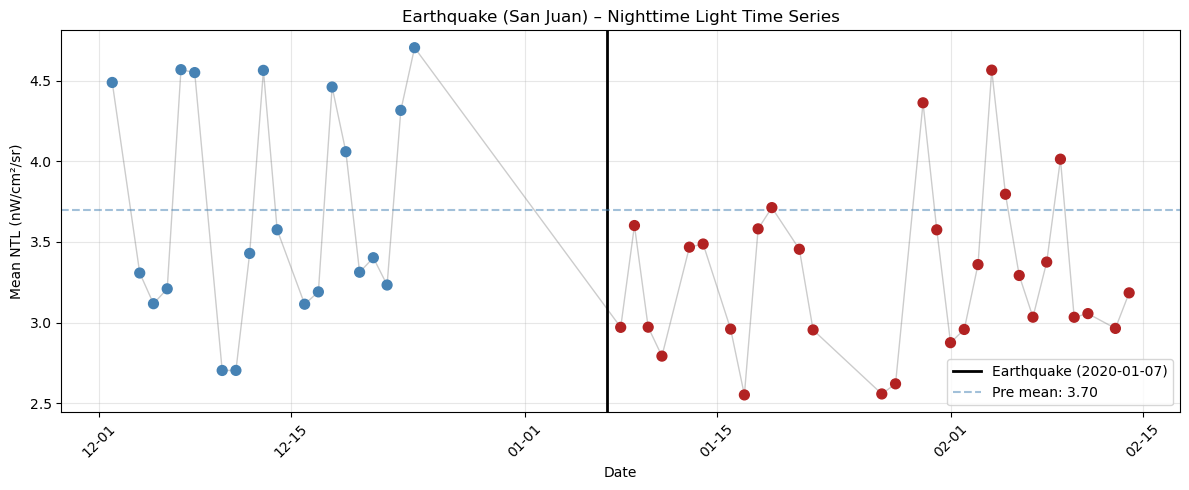

Pre mean NTL: 3.701


In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = df_stats['period'].map({'pre': 'steelblue', 'post': 'firebrick'})
ax.scatter(df_stats['date'], df_stats['mean_ntl'], c=colors, s=50, zorder=5)
ax.plot(df_stats['date'], df_stats['mean_ntl'], color='gray', alpha=0.4, linewidth=1)

ax.axvline(x=LANDFALL_DATE, color='black', linestyle='-', lw=2, label='Earthquake (2020-01-07)')
pre_mean = df_stats[df_stats['period'] == 'pre']['mean_ntl'].mean()
ax.axhline(y=pre_mean, color='steelblue', linestyle='--', alpha=0.5, label=f'Pre mean: {pre_mean:.2f}')

ax.set_xlabel('Date')
ax.set_ylabel('Mean NTL (nW/cm²/sr)')
ax.set_title(f'{EVENT_NAME} – Nighttime Light Time Series')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ntl_timeseries_overall.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Pre mean NTL: {pre_mean:.3f}')

## 6. Critical Infrastructure POI

Query OpenStreetMap Overpass API. Fallback to curated list if API fails.
Categories: hospital, clinic, fire_station, police, government, airport, utilities.
**No schools.**

In [27]:
# =============================================================================
# Overpass API query
# =============================================================================
south, west, north, east = BOUNDS[1], BOUNDS[0], BOUNDS[3], BOUNDS[2]
bbox_str = f'{south},{west},{north},{east}'

overpass_query = f"""
[out:json][timeout:60];
(
  node["amenity"="hospital"]({bbox_str});
  way["amenity"="hospital"]({bbox_str});
  node["amenity"="clinic"]({bbox_str});
  way["amenity"="clinic"]({bbox_str});
  node["amenity"="fire_station"]({bbox_str});
  way["amenity"="fire_station"]({bbox_str});
  node["amenity"="police"]({bbox_str});
  way["amenity"="police"]({bbox_str});
  node["amenity"="townhall"]({bbox_str});
  way["amenity"="townhall"]({bbox_str});
  node["office"="government"]({bbox_str});
  way["office"="government"]({bbox_str});
  node["aeroway"="aerodrome"]({bbox_str});
  way["aeroway"="aerodrome"]({bbox_str});
  relation["aeroway"="aerodrome"]({bbox_str});
  node["man_made"="water_works"]({bbox_str});
  way["man_made"="water_works"]({bbox_str});
  node["power"="plant"]({bbox_str});
  way["power"="plant"]({bbox_str});
  node["power"="substation"]({bbox_str});
  way["power"="substation"]({bbox_str});
);
out center;
"""

url = 'https://overpass-api.de/api/interpreter'
poi_df = None

for attempt in range(3):
    response = requests.post(url, data={'data': overpass_query}, timeout=120)
    if response.status_code == 200:
        try:
            data = response.json()
            pois = []
            for elem in data['elements']:
                lat = elem.get('lat') or elem.get('center', {}).get('lat')
                lon = elem.get('lon') or elem.get('center', {}).get('lon')
                if lat is None or lon is None:
                    continue
                tags = elem.get('tags', {})
                ftype = (tags.get('amenity') or tags.get('office') or
                         tags.get('man_made') or tags.get('power') or
                         tags.get('aeroway') or 'unknown')
                pois.append({
                    'osm_id': elem['id'],
                    'name': tags.get('name', 'unnamed'),
                    'type': ftype,
                    'lat': lat,
                    'lon': lon,
                })
            if pois:
                poi_df = pd.DataFrame(pois)
                print(f'Overpass API success: {len(poi_df)} POIs')
                break
        except:
            pass
    print(f'Attempt {attempt+1} failed, retrying in 30s...')
    time.sleep(30)

# Fallback
if poi_df is None or len(poi_df) == 0:
    print('Using fallback POI list')
    poi_df = pd.DataFrame([
        {'name': 'Centro Médico', 'type': 'hospital', 'lat': 18.3963, 'lon': -66.0753},
        {'name': 'Hospital Auxilio Mutuo', 'type': 'hospital', 'lat': 18.4053, 'lon': -66.0611},
        {'name': 'Hospital San Jorge', 'type': 'hospital', 'lat': 18.3925, 'lon': -66.0682},
        {'name': 'VA Medical Center', 'type': 'hospital', 'lat': 18.3983, 'lon': -66.0744},
        {'name': 'Hospital Pavia', 'type': 'hospital', 'lat': 18.4255, 'lon': -66.0553},
        {'name': 'Hospital HIMA San Pablo', 'type': 'hospital', 'lat': 18.3811, 'lon': -66.0467},
        {'name': 'San Juan Police HQ', 'type': 'police', 'lat': 18.4496, 'lon': -66.0641},
        {'name': 'PR Police Headquarters', 'type': 'police', 'lat': 18.4291, 'lon': -66.0590},
        {'name': 'Bomberos San Juan', 'type': 'fire_station', 'lat': 18.4475, 'lon': -66.0726},
        {'name': 'Estación Bomberos Hato Rey', 'type': 'fire_station', 'lat': 18.4100, 'lon': -66.0590},
        {'name': 'Capitolio de PR', 'type': 'government', 'lat': 18.4597, 'lon': -66.0871},
        {'name': 'La Fortaleza', 'type': 'government', 'lat': 18.4655, 'lon': -66.1168},
        {'name': 'Luis Muñoz Marín Airport', 'type': 'aerodrome', 'lat': 18.4394, 'lon': -66.0018},
        {'name': 'Fernando L. Ribas Dominicci Airport', 'type': 'aerodrome', 'lat': 18.4573, 'lon': -66.0985},
        {'name': 'AEE Central Palo Seco', 'type': 'plant', 'lat': 18.4410, 'lon': -66.1300},
        {'name': 'San Juan Water Treatment', 'type': 'water_works', 'lat': 18.3950, 'lon': -66.0550},
    ])

print(f'\nPOIs by type:')
print(poi_df['type'].value_counts())

poi_csv = OUT_DIR / 'san_juan_critical_infra_poi.csv'
poi_df.to_csv(poi_csv, index=False)
print(f'\n✓ Saved to {poi_csv}')

Overpass API success: 434 POIs

POIs by type:
type
government         120
clinic             113
substation          95
police              45
hospital            28
fire_station        12
townhall             8
plant                7
aerodrome            3
water_works          2
public_building      1
Name: count, dtype: int64

✓ Saved to ../result/san_juan_critical_infra_poi.csv


## 7. Create Differentiated Buffers by Facility Type

In [28]:
# =============================================================================
# Build GeoDataFrame and create buffers
# =============================================================================
gdf_poi = gpd.GeoDataFrame(
    poi_df,
    geometry=gpd.points_from_xy(poi_df['lon'], poi_df['lat']),
    crs='EPSG:4326'
)

gdf_poi_m = gdf_poi.to_crs(METRIC_CRS)

# Assign buffer radius per POI
gdf_poi_m['buffer_radius'] = gdf_poi_m['type'].map(
    lambda t: BUFFER_RADII.get(t, DEFAULT_BUFFER)
)
gdf_poi_m['buffer_geom'] = gdf_poi_m.apply(
    lambda row: row.geometry.buffer(row['buffer_radius']), axis=1
)

print('Buffer radius by type:')
for ftype, group in gdf_poi_m.groupby('type'):
    r = group['buffer_radius'].iloc[0]
    print(f'  {ftype}: {r}m ({len(group)} facilities)')

# Buffer union per type
buffer_by_type = {}
for ftype, group in gdf_poi_m.groupby('type'):
    union = group['buffer_geom'].unary_union
    area_km2 = union.area / 1e6
    buffer_by_type[ftype] = union
    print(f'  {ftype} buffer area: {area_km2:.2f} km²')

# Overall buffer union
buffer_union = gdf_poi_m['buffer_geom'].unary_union
total_buffer_area_km2 = buffer_union.area / 1e6
print(f'\nTotal buffer area (all): {total_buffer_area_km2:.2f} km²')

Buffer radius by type:
  aerodrome: 1250m (3 facilities)
  clinic: 750m (113 facilities)
  fire_station: 750m (12 facilities)
  government: 750m (120 facilities)
  hospital: 750m (28 facilities)
  plant: 750m (7 facilities)
  police: 750m (45 facilities)
  public_building: 750m (1 facilities)
  substation: 750m (95 facilities)
  townhall: 750m (8 facilities)
  water_works: 750m (2 facilities)
  aerodrome buffer area: 14.68 km²
  clinic buffer area: 81.47 km²
  fire_station buffer area: 19.44 km²
  government buffer area: 75.38 km²
  hospital buffer area: 45.74 km²
  plant buffer area: 9.03 km²
  police buffer area: 62.33 km²
  public_building buffer area: 1.76 km²
  substation buffer area: 107.72 km²
  townhall buffer area: 11.11 km²
  water_works buffer area: 3.53 km²

Total buffer area (all): 198.36 km²


## 7b. Buffer Map (Satellite Basemap)

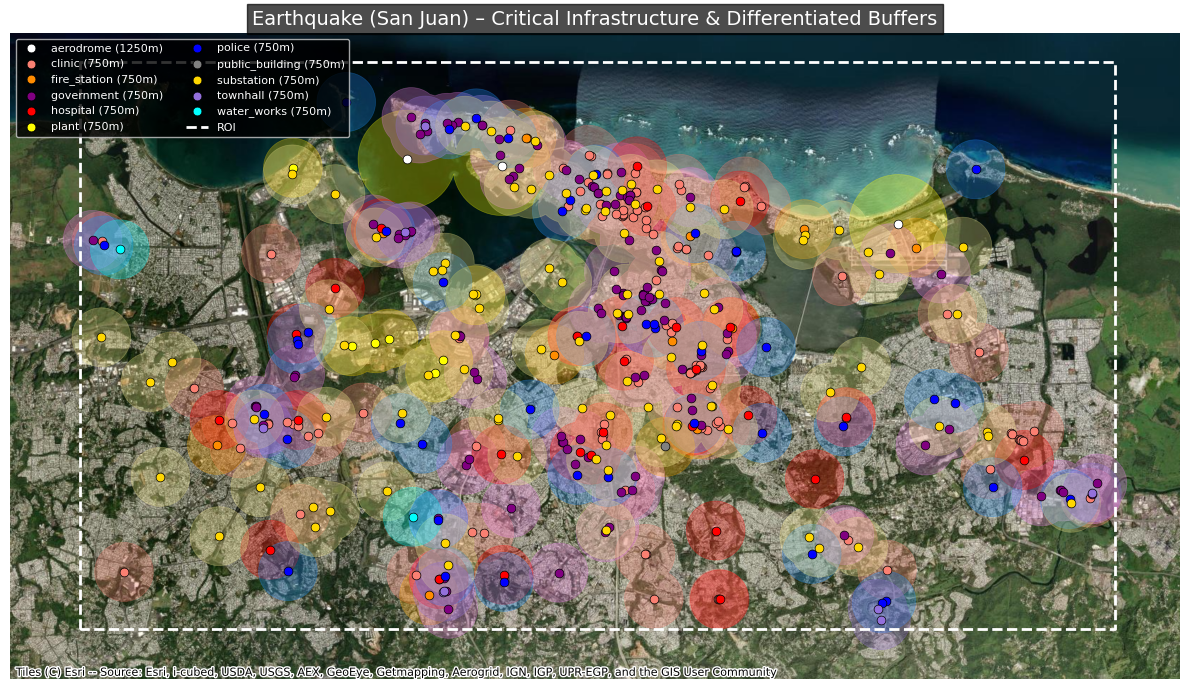

In [29]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot per-type buffers with different colors
buf_colors = {
    'aerodrome': 'yellow', 'hospital': 'red', 'clinic': 'salmon',
    'fire_station': 'orange', 'police': 'dodgerblue',
    'government': 'violet', 'townhall': 'mediumpurple',
    'water_works': 'cyan', 'plant': 'gold', 'substation': 'khaki',
}

for ftype, buf_geom in buffer_by_type.items():
    color = buf_colors.get(ftype, 'orange')
    gs = gpd.GeoSeries([buf_geom], crs=METRIC_CRS).to_crs('EPSG:3857')
    gs.plot(ax=ax, color=color, alpha=0.3, edgecolor=color, linewidth=0.5)

# Plot POI points
gdf_poi_3857 = gdf_poi.to_crs('EPSG:3857')
type_colors = {
    'hospital': 'red', 'clinic': 'salmon',
    'fire_station': 'darkorange', 'police': 'blue',
    'government': 'purple', 'townhall': 'mediumpurple',
    'aerodrome': 'white',
    'water_works': 'cyan', 'plant': 'yellow', 'substation': 'gold',
}

for ftype, group in gdf_poi_3857.groupby(poi_df['type']):
    color = type_colors.get(ftype, 'gray')
    radius = BUFFER_RADII.get(ftype, DEFAULT_BUFFER)
    group.plot(ax=ax, color=color, markersize=40, label=f'{ftype} ({radius}m)',
              edgecolor='black', linewidth=0.5, zorder=5)

# ROI box
roi_3857 = gpd.GeoSeries([box(*BOUNDS)], crs='EPSG:4326').to_crs('EPSG:3857')
roi_3857.boundary.plot(ax=ax, color='white', linewidth=2, linestyle='--', label='ROI')

# Satellite basemap
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=13)

ax.set_axis_off()
ax.set_title(
    f'{EVENT_NAME} – Critical Infrastructure & Differentiated Buffers',
    fontsize=14, color='white',
    bbox=dict(facecolor='black', alpha=0.7)
)
ax.legend(loc='upper left', fontsize=8, ncol=2, facecolor='black', labelcolor='white')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'poi_buffer_map.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Buffer vs Non-buffer NTL (Per Facility Type)

In [30]:
def zonal_nanmean(src, geom_metric):
    """Compute nanmean of raster values within a geometry."""
    try:
        geom_raster = (
            gpd.GeoSeries([geom_metric], crs=METRIC_CRS)
            .to_crs(src.crs)
            .iloc[0]
        )
        out, _ = mask(src, [geom_raster], crop=False, all_touched=True)
        arr = out[0].astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        arr[arr < 0] = np.nan
        return float(np.nanmean(arr))
    except Exception:
        return np.nan


buf_records = []
error_count = 0

for idx, row in imgs.iterrows():
    try:
        with rasterio.open(row['path']) as src:
            raster_extent_m = (
                gpd.GeoSeries([box(*src.bounds)], crs=src.crs)
                .to_crs(METRIC_CRS)
                .iloc[0]
            )

            # Per-type
            for ftype, buf_geom in buffer_by_type.items():
                nonbuf_geom = raster_extent_m.difference(buf_geom)
                buf_records.append({
                    'date': row['date'],
                    'period': row['period'],
                    'facility_type': ftype,
                    'buffer_ntl': zonal_nanmean(src, buf_geom),
                    'nonbuffer_ntl': zonal_nanmean(src, nonbuf_geom) if not nonbuf_geom.is_empty else np.nan,
                })

            # All combined
            nonbuf_all = raster_extent_m.difference(buffer_union)
            buf_records.append({
                'date': row['date'],
                'period': row['period'],
                'facility_type': '_all_combined',
                'buffer_ntl': zonal_nanmean(src, buffer_union),
                'nonbuffer_ntl': zonal_nanmean(src, nonbuf_all) if not nonbuf_all.is_empty else np.nan,
            })

    except Exception as e:
        print(f'Error: {row["filename"]}: {e}')
        error_count += 1

df_buf = pd.DataFrame(buf_records)
print(f'Processed {len(imgs)} images x {len(buffer_by_type)+1} types ({error_count} errors)')
print(f'Total records: {len(df_buf)}')

Processed 49 images x 12 types (0 errors)
Total records: 588


## 9. Resilience Calculation (Per Type)

In [31]:
# Pre-disaster baselines per type
baselines = df_buf[df_buf['period'] == 'pre'].groupby('facility_type').agg(
    pre_buf=('buffer_ntl', 'mean'),
    pre_nobuf=('nonbuffer_ntl', 'mean'),
).to_dict('index')

df_buf['resilience_buffer'] = df_buf.apply(
    lambda r: r['buffer_ntl'] / baselines[r['facility_type']]['pre_buf']
    if r['facility_type'] in baselines and baselines[r['facility_type']]['pre_buf'] > 0
    else np.nan, axis=1
)
df_buf['resilience_nonbuffer'] = df_buf.apply(
    lambda r: r['nonbuffer_ntl'] / baselines[r['facility_type']]['pre_nobuf']
    if r['facility_type'] in baselines and baselines[r['facility_type']]['pre_nobuf'] > 0
    else np.nan, axis=1
)

print('Pre-disaster baselines by type:')
for ftype, vals in baselines.items():
    print(f'  {ftype}: buffer={vals["pre_buf"]:.3f}, non-buffer={vals["pre_nobuf"]:.3f}')

Pre-disaster baselines by type:
  _all_combined: buffer=3.066, non-buffer=1.805
  aerodrome: buffer=0.200, non-buffer=3.592
  clinic: buffer=1.709, non-buffer=3.056
  fire_station: buffer=0.528, non-buffer=3.596
  government: buffer=1.603, non-buffer=3.006
  hospital: buffer=1.139, non-buffer=3.425
  plant: buffer=0.210, non-buffer=3.645
  police: buffer=1.467, non-buffer=3.337
  public_building: buffer=0.035, non-buffer=3.695
  substation: buffer=2.183, non-buffer=2.836
  townhall: buffer=0.223, non-buffer=3.647
  water_works: buffer=0.059, non-buffer=3.689


## 10. NTL Time Series by Facility Type

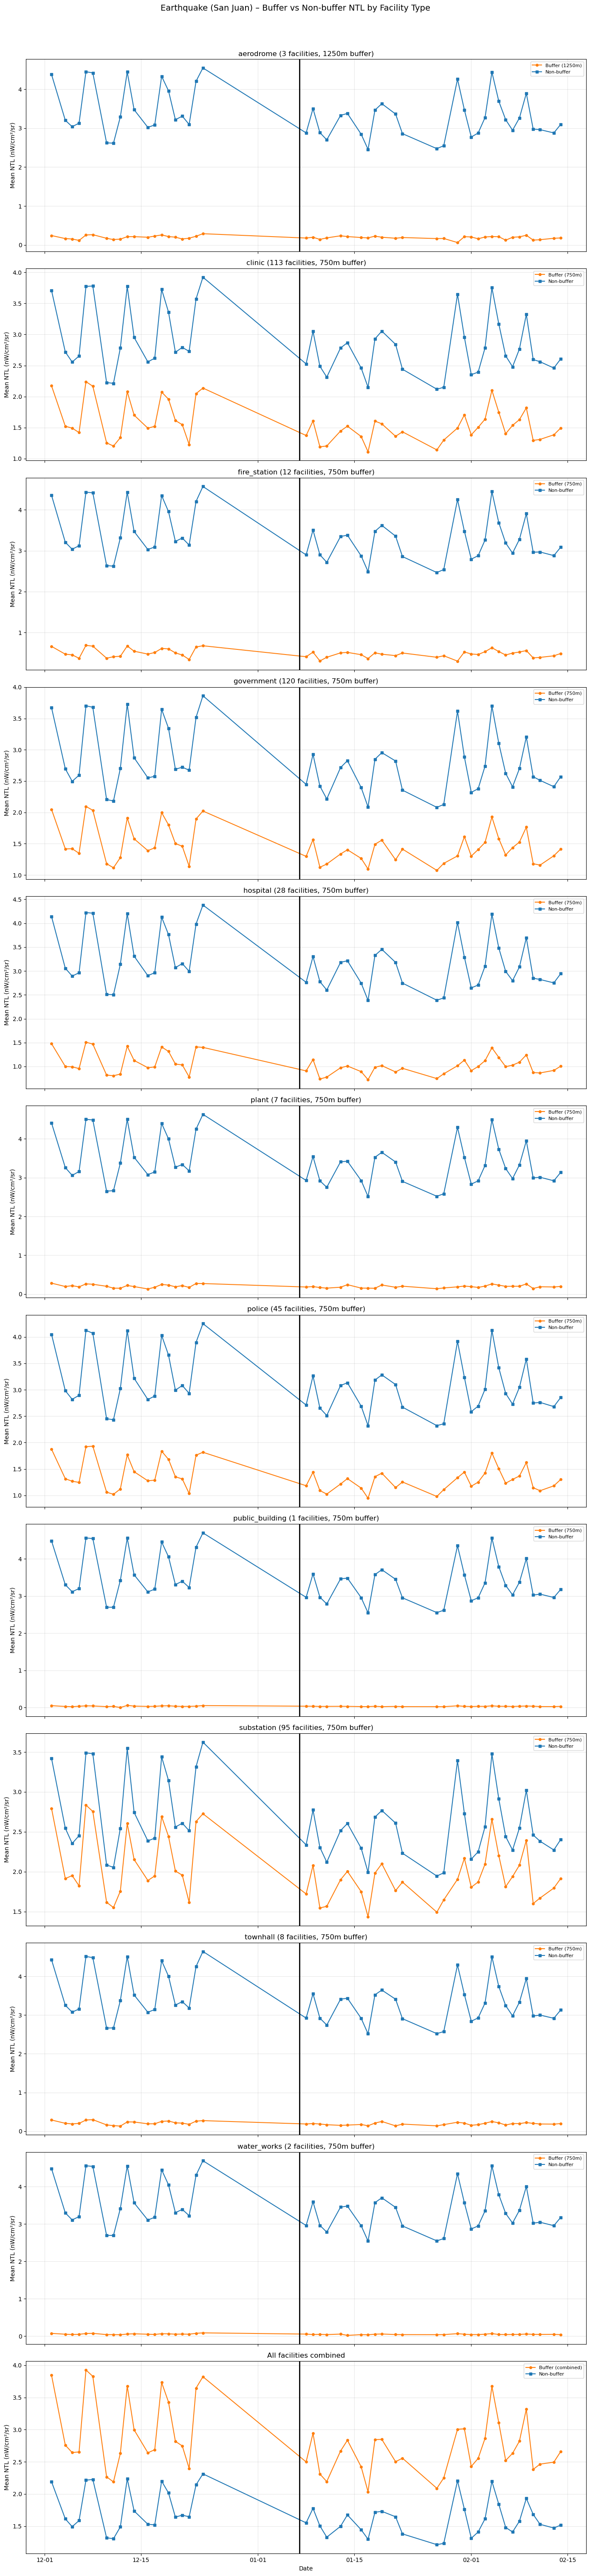

In [32]:
facility_types = [t for t in df_buf['facility_type'].unique() if t != '_all_combined']
n_types = len(facility_types) + 1  # +1 for combined

fig, axes = plt.subplots(n_types, 1, figsize=(14, 5 * n_types), sharex=True)
if n_types == 1:
    axes = [axes]

for i, ftype in enumerate(facility_types):
    ax = axes[i]
    data = df_buf[df_buf['facility_type'] == ftype].sort_values('date')
    n_fac = len(gdf_poi_m[gdf_poi_m['type'] == ftype])
    radius = BUFFER_RADII.get(ftype, DEFAULT_BUFFER)

    ax.plot(data['date'], data['buffer_ntl'], marker='o', linewidth=1.5,
            color='tab:orange', label=f'Buffer ({radius}m)', markersize=4)
    ax.plot(data['date'], data['nonbuffer_ntl'], marker='s', linewidth=1.5,
            color='tab:blue', label='Non-buffer', markersize=4)
    ax.axvline(x=LANDFALL_DATE, color='black', linestyle='-', lw=2)
    ax.set_ylabel('Mean NTL (nW/cm²/sr)')
    ax.set_title(f'{ftype} ({n_fac} facilities, {radius}m buffer)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Combined
ax = axes[-1]
data = df_buf[df_buf['facility_type'] == '_all_combined'].sort_values('date')
ax.plot(data['date'], data['buffer_ntl'], marker='o', linewidth=1.5,
        color='tab:orange', label='Buffer (combined)', markersize=4)
ax.plot(data['date'], data['nonbuffer_ntl'], marker='s', linewidth=1.5,
        color='tab:blue', label='Non-buffer', markersize=4)
ax.axvline(x=LANDFALL_DATE, color='black', linestyle='-', lw=2)
ax.set_ylabel('Mean NTL (nW/cm²/sr)')
ax.set_title('All facilities combined')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.suptitle(f'{EVENT_NAME} – Buffer vs Non-buffer NTL by Facility Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ntl_buffer_by_type_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()

## 11. Resilience Curves by Facility Type

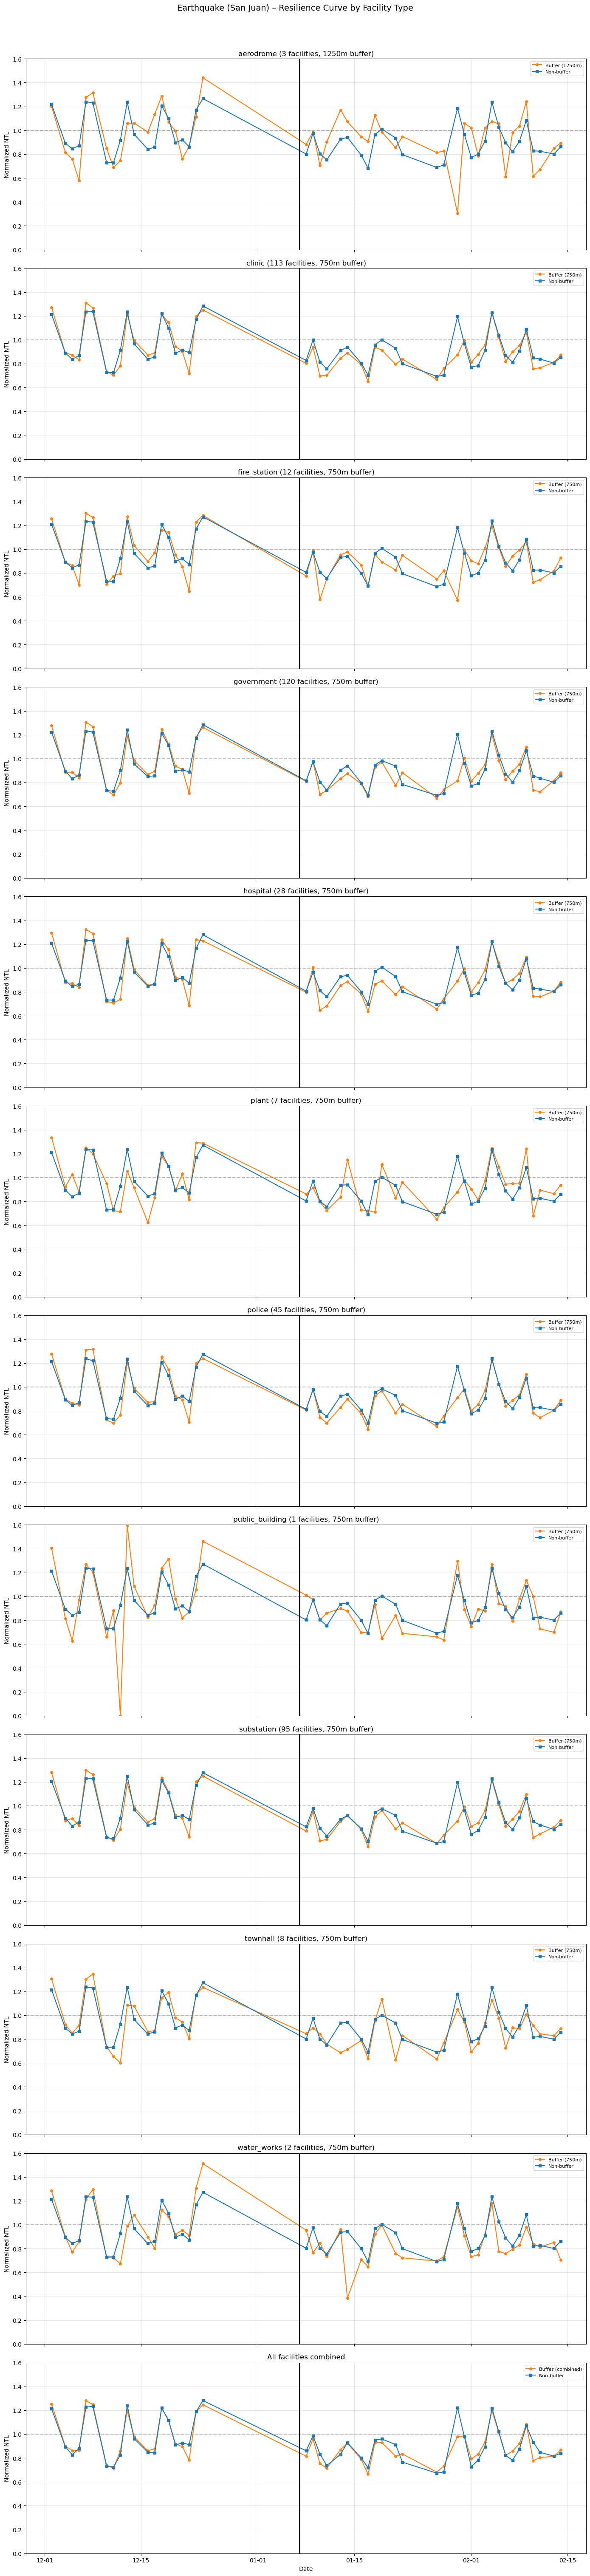

In [33]:
fig, axes = plt.subplots(n_types, 1, figsize=(14, 5 * n_types), sharex=True)
if n_types == 1:
    axes = [axes]

for i, ftype in enumerate(facility_types):
    ax = axes[i]
    data = df_buf[df_buf['facility_type'] == ftype].sort_values('date')
    n_fac = len(gdf_poi_m[gdf_poi_m['type'] == ftype])
    radius = BUFFER_RADII.get(ftype, DEFAULT_BUFFER)

    ax.plot(data['date'], data['resilience_buffer'], marker='o', linewidth=1.5,
            color='tab:orange', label=f'Buffer ({radius}m)', markersize=4)
    ax.plot(data['date'], data['resilience_nonbuffer'], marker='s', linewidth=1.5,
            color='tab:blue', label='Non-buffer', markersize=4)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=LANDFALL_DATE, color='black', linestyle='-', lw=2)
    ax.set_ylabel('Normalized NTL')
    ax.set_title(f'{ftype} ({n_fac} facilities, {radius}m buffer)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.6)

# Combined
ax = axes[-1]
data = df_buf[df_buf['facility_type'] == '_all_combined'].sort_values('date')
ax.plot(data['date'], data['resilience_buffer'], marker='o', linewidth=1.5,
        color='tab:orange', label='Buffer (combined)', markersize=4)
ax.plot(data['date'], data['resilience_nonbuffer'], marker='s', linewidth=1.5,
        color='tab:blue', label='Non-buffer', markersize=4)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=LANDFALL_DATE, color='black', linestyle='-', lw=2)
ax.set_ylabel('Normalized NTL')
ax.set_title('All facilities combined')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.6)
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.suptitle(f'{EVENT_NAME} – Resilience Curve by Facility Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'resilience_curve_by_type.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Resilience Summary by Facility Type

In [34]:
summary_rows = []
for ftype in facility_types + ['_all_combined']:
    data = df_buf[df_buf['facility_type'] == ftype]
    pre_data = data[data['period'] == 'pre']
    post_data = data[data['period'] == 'post']

    n_fac = len(gdf_poi_m[gdf_poi_m['type'] == ftype]) if ftype != '_all_combined' else len(gdf_poi_m)
    radius = BUFFER_RADII.get(ftype, DEFAULT_BUFFER) if ftype != '_all_combined' else 'mixed'

    row = {
        'facility_type': ftype,
        'n_facilities': n_fac,
        'buffer_radius': radius,
        'pre_buffer_ntl': pre_data['buffer_ntl'].mean(),
        'pre_nonbuffer_ntl': pre_data['nonbuffer_ntl'].mean(),
        'post_buffer_ntl': post_data['buffer_ntl'].mean(),
        'post_nonbuffer_ntl': post_data['nonbuffer_ntl'].mean(),
        'resilience_buffer': post_data['resilience_buffer'].mean(),
        'resilience_nonbuffer': post_data['resilience_nonbuffer'].mean(),
    }
    row['resilience_advantage'] = row['resilience_buffer'] - row['resilience_nonbuffer']
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print('=' * 80)
print(f'{EVENT_NAME} – Resilience by Facility Type')
print('=' * 80)
display(df_summary[[
    'facility_type', 'n_facilities', 'buffer_radius',
    'resilience_buffer', 'resilience_nonbuffer', 'resilience_advantage'
]].round(4))

df_summary.to_csv(OUT_DIR / 'resilience_by_facility_type.csv', index=False)
df_buf.to_csv(OUT_DIR / 'maria_sanjuan_ntl_by_type.csv', index=False)
print(f'\n✓ Saved to {OUT_DIR}')

Earthquake (San Juan) – Resilience by Facility Type


,facility_type,n_facilities,buffer_radius,resilience_buffer,resilience_nonbuffer,resilience_advantage
0,aerodrome,3,1250,0.9087,0.8864,0.0223
1,clinic,113,750,0.8597,0.8875,-0.0279
2,fire_station,12,750,0.8761,0.8864,-0.0103
3,government,120,750,0.8600,0.8829,-0.0229
4,hospital,28,750,0.8593,0.8847,-0.0254
5,plant,7,750,0.8994,0.8862,0.0132
6,police,45,750,0.8650,0.8847,-0.0197
7,public_building,1,750,0.8706,0.8863,-0.0156
8,substation,95,750,0.8651,0.8808,-0.0157
9,townhall,8,750,0.8479,0.8855,-0.0376



✓ Saved to ../result


## 13. NTL Change Ratio (Zhang et al. 2023)

```
relative_NTL_change = (Rad_pre - Rad_post) / Rad_pre
```
Uses pre-disaster median composite and **best** post image (max valid pixels).

In [35]:
pre_tifs = imgs[imgs['period'] == 'pre']['path'].tolist()
post_imgs_df = imgs[imgs['period'] == 'post'].copy()

if len(pre_tifs) == 0 or len(post_imgs_df) == 0:
    print('ERROR: need at least 1 pre and 1 post image')
else:
    # Pre composite (pixel-wise median)
    with rasterio.open(pre_tifs[0]) as ref:
        profile = ref.profile.copy()
        shape = ref.read(1).shape

    pre_stack = []
    for p in pre_tifs:
        with rasterio.open(p) as src:
            arr = src.read(1).astype('float32')
            if src.nodata is not None:
                arr[arr == src.nodata] = np.nan
            arr[arr < 0] = np.nan
            pre_stack.append(arr)
    pre_composite = np.nanmedian(np.stack(pre_stack), axis=0)
    print(f'Pre composite: median of {len(pre_stack)} images')

    # Best post image (highest valid pixel fraction)
    best_valid = 0
    best_idx = post_imgs_df.index[0]
    for i, row in post_imgs_df.iterrows():
        with rasterio.open(row['path']) as src:
            arr = src.read(1).astype('float32')
            if src.nodata is not None:
                arr[arr == src.nodata] = np.nan
            arr[arr < 0] = np.nan
            vfrac = np.count_nonzero(~np.isnan(arr)) / arr.size
            if vfrac > best_valid:
                best_valid = vfrac
                best_idx = i

    first_post_path = post_imgs_df.loc[best_idx, 'path']
    print(f'Selected post image: {Path(first_post_path).name} (valid: {best_valid:.1%})')

    with rasterio.open(first_post_path) as src:
        post_arr = src.read(1).astype('float32')
        if src.nodata is not None:
            post_arr[post_arr == src.nodata] = np.nan
        post_arr[post_arr < 0] = np.nan

    # Change ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        change_ratio = (pre_composite - post_arr) / pre_composite
    change_ratio[~np.isfinite(change_ratio)] = np.nan

    print(f'\nChange ratio stats:')
    print(f'  Mean:   {np.nanmean(change_ratio):.3f}')
    print(f'  Median: {np.nanmedian(change_ratio):.3f}')
    n_valid = np.count_nonzero(~np.isnan(change_ratio))
    print(f'  Affected (>10%): {np.nansum(change_ratio > 0.1) / n_valid * 100:.1f}%')

Pre composite: median of 20 images
Selected post image: maria_sanjuan_post_2020-02-07.tif (valid: 100.0%)

Change ratio stats:
  Mean:   0.150
  Median: 0.210
  Affected (>10%): 65.3%


## 14. NTL Change Ratio Map

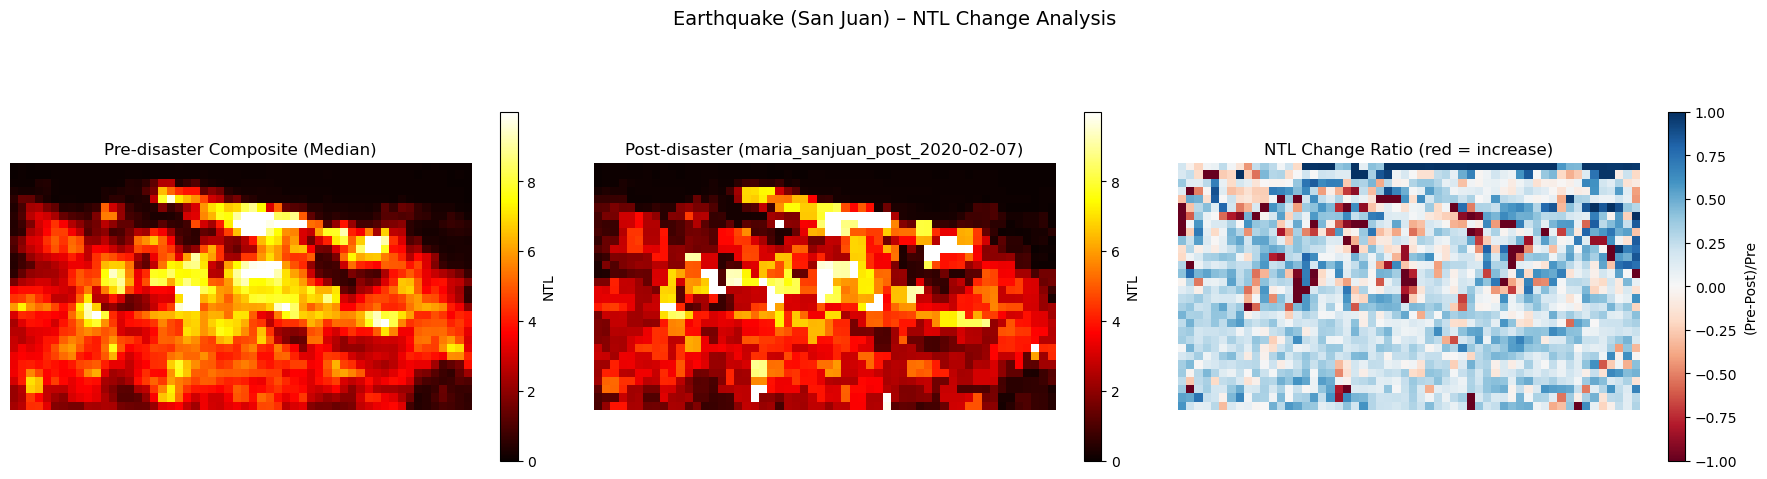

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(pre_composite, cmap='hot', vmin=0, vmax=np.nanpercentile(pre_composite, 98))
axes[0].set_title('Pre-disaster Composite (Median)')
plt.colorbar(im0, ax=axes[0], label='NTL', shrink=0.8)

im1 = axes[1].imshow(post_arr, cmap='hot', vmin=0, vmax=np.nanpercentile(pre_composite, 98))
axes[1].set_title(f'Post-disaster ({Path(first_post_path).stem})')
plt.colorbar(im1, ax=axes[1], label='NTL', shrink=0.8)

im2 = axes[2].imshow(change_ratio, cmap='RdBu', vmin=-1, vmax=1)
axes[2].set_title('NTL Change Ratio (red = increase)')
plt.colorbar(im2, ax=axes[2], label='(Pre-Post)/Pre', shrink=0.8)

for ax in axes:
    ax.axis('off')

plt.suptitle(f'{EVENT_NAME} – NTL Change Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ntl_change_ratio_map.png', dpi=200, bbox_inches='tight')
plt.show()

## 15. Save Change Ratio as GeoTIFF

In [37]:
out_profile = profile.copy()
out_profile.update(dtype='float32', count=1, nodata=np.nan)

out_path = OUT_DIR / 'ntl_change_ratio.tif'
with rasterio.open(out_path, 'w', **out_profile) as dst:
    dst.write(change_ratio.astype('float32'), 1)

print(f'✓ Change ratio saved to {out_path}')

✓ Change ratio saved to ../result/ntl_change_ratio.tif


## 16. Investigate Brighter Pixels

Find pixels that got **brighter** after the disaster and overlay on satellite
imagery to investigate what they correspond to.

In [38]:
# =============================================================================
# Extract brighter pixels
# =============================================================================
BRIGHT_THRESHOLD = -0.1  # change_ratio < -0.1 means >10% brighter

brighter_mask = change_ratio < BRIGHT_THRESHOLD
n_brighter = np.nansum(brighter_mask)
n_valid = np.count_nonzero(~np.isnan(change_ratio))
print(f'Pixels that got brighter (>{abs(BRIGHT_THRESHOLD)*100:.0f}% increase): '
      f'{n_brighter} / {n_valid} ({n_brighter/n_valid*100:.1f}%)')

# Get raster georeferencing
with rasterio.open(pre_tifs[0]) as ref:
    transform = ref.transform
    raster_crs = ref.crs

# Convert to GeoDataFrame
rows, cols = np.where(brighter_mask)
xs, ys = rasterio.transform.xy(transform, rows, cols)
brightness_vals = change_ratio[brighter_mask]

gdf_bright = gpd.GeoDataFrame(
    {
        'change_ratio': brightness_vals,
        'brightness_increase_pct': -brightness_vals * 100,
    },
    geometry=gpd.points_from_xy(xs, ys),
    crs=raster_crs,
)

gdf_bright_3857 = gdf_bright.to_crs('EPSG:3857')

print(f'\nBrightness increase stats:')
print(f'  Mean:   {gdf_bright["brightness_increase_pct"].mean():.1f}%')
print(f'  Median: {gdf_bright["brightness_increase_pct"].median():.1f}%')
print(f'  Max:    {gdf_bright["brightness_increase_pct"].max():.1f}%')

Pixels that got brighter (>10% increase): 273 / 1680 (16.2%)

Brightness increase stats:
  Mean:   57.3%
  Median: 36.5%
  Max:    314.0%


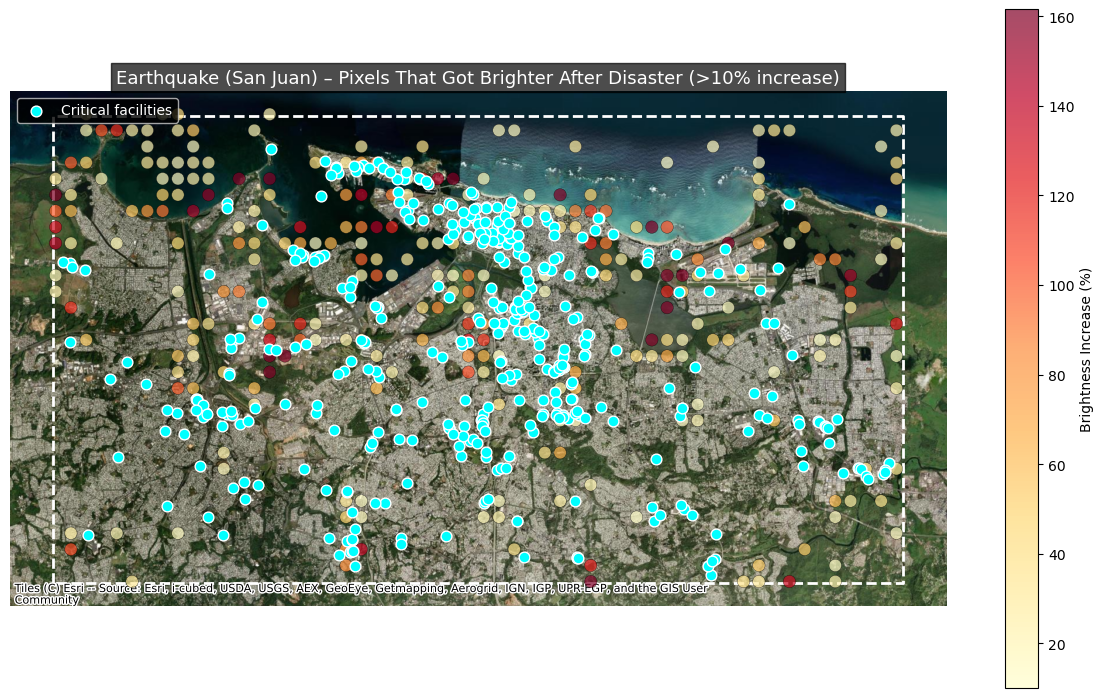


Total brighter pixels plotted: 273


In [39]:
fig, ax = plt.subplots(figsize=(12, 10))

# Brighter pixels
scatter = ax.scatter(
    gdf_bright_3857.geometry.x,
    gdf_bright_3857.geometry.y,
    c=gdf_bright_3857['brightness_increase_pct'],
    cmap='YlOrRd',
    s=80,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3,
    vmin=10,
    vmax=gdf_bright_3857['brightness_increase_pct'].quantile(0.95),
    zorder=5,
)
plt.colorbar(scatter, ax=ax, label='Brightness Increase (%)', shrink=0.7)

# Overlay POI
gdf_poi_3857 = gdf_poi.to_crs('EPSG:3857')
gdf_poi_3857.plot(ax=ax, color='cyan', markersize=60, edgecolor='white',
                  linewidth=1, zorder=6, label='Critical facilities')

# ROI boundary
roi_3857 = gpd.GeoSeries([box(*BOUNDS)], crs='EPSG:4326').to_crs('EPSG:3857')
roi_3857.boundary.plot(ax=ax, color='white', linewidth=2, linestyle='--')

# Satellite basemap
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=13)

ax.set_axis_off()
ax.set_title(
    f'{EVENT_NAME} – Pixels That Got Brighter After Disaster (>{abs(BRIGHT_THRESHOLD)*100:.0f}% increase)',
    fontsize=13, color='white',
    bbox=dict(facecolor='black', alpha=0.7)
)
ax.legend(loc='upper left', fontsize=10, facecolor='black', labelcolor='white')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'brighter_pixels_map.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nTotal brighter pixels plotted: {len(gdf_bright)}')

# ## 17. BEAST Time Series Decomposition
#
# Apply BEAST (Bayesian Estimator of Abrupt change, Seasonal change, and Trend)
# to decompose NTL time series into trend + seasonal + remainder.
#
# **Why BEAST?**
# - Handles irregular time series with missing data (~30% cloud gaps)
# - Separates seasonal/noise from true trend → solves "brighter during outage" problem
# - Provides change point detection with occurrence probability
# - BAU (Business-As-Usual) trend projection for standardized resilience metric
#
# **Approach:** Simplified version — run BEAST on aggregated buffer / non-buffer
# time series (one per facility type), not per-pixel.
#
# Reference: Zhao et al. 2019; Zheng et al. 2025 (RSE 319)